# Sentiment analysis: opinions on vaksin campak (measles/MR vaccine)

Loads `cleaned_data.csv` (the merged, topic-filtered dataset across X/Threads/Instagram/Facebook),
scores each row's sentiment toward vaksin campak using a pretrained Indonesian sentiment model,
and aggregates the result into a weekly positive-vs-negative figure.

**Comment handling**: rows where `replysource` is not null are comments/replies. A short reply like
"iya aku setuju" carries no sentiment signal on its own — its parent post (matched via
`replysource == link`) is prepended before scoring, so the reply is read in context. This mirrors
the same approach used earlier in `classify/classify_relevance.py` for topic relevance.

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from transformers import pipeline

pd.set_option('display.max_colwidth', 120)

## 1. Load data

In [2]:
df = pd.read_csv('cleaned_data.csv')
df['tweet'] = df['tweet'].fillna('').astype(str)
print(df.shape)
df['platform'].value_counts()

(10471, 12)


platform
threads      8170
x            1188
facebook     1106
instagram       7
Name: count, dtype: int64

## 2. Build context text for comments

For any row where `replysource` is a real link (not null), look up the row whose `link` matches it
and prepend that parent post's text. Falls back to the row's own text if no matching parent is
found in this file (comment-fetching sometimes kept replies whose parent post got filtered out or
de-duplicated elsewhere in the merge).

In [3]:
link_to_text = dict(zip(df['link'].astype(str), df['tweet']))

def build_context(row):
    rs = row['replysource']
    if pd.isna(rs):
        return row['tweet']
    parent_text = link_to_text.get(str(rs))
    if parent_text:
        return f"{parent_text} — Balasan: {row['tweet']}"
    return row['tweet']

df['context_text'] = df.apply(build_context, axis=1)

is_comment = df['replysource'].notna()
has_parent = is_comment & df['replysource'].astype(str).isin(link_to_text)
print(f"comments: {is_comment.sum()} / {len(df)}")
print(f"  of which, parent found in this file: {has_parent.sum()}")
print(f"  of which, parent NOT found (falls back to own text): {(is_comment & ~has_parent).sum()}")

comments: 9540 / 10471
  of which, parent found in this file: 3716
  of which, parent NOT found (falls back to own text): 5824


## 3. Sentiment model

Uses `mdhugol/indonesia-bert-sentiment-classification` (IndoBERT fine-tuned on the IndoNLU SmSA
sentiment dataset). Label mapping verified manually against known-positive/negative/neutral
examples before trusting it: `LABEL_0=positive, LABEL_1=neutral, LABEL_2=negative`.

In [4]:
device = 'mps' if torch.backends.mps.is_available() else (0 if torch.cuda.is_available() else -1)

sentiment_clf = pipeline(
    'sentiment-analysis',
    model='mdhugol/indonesia-bert-sentiment-classification',
    device=device,
    truncation=True,
    max_length=512,
)

LABEL_MAP = {'LABEL_0': 'positive', 'LABEL_1': 'neutral', 'LABEL_2': 'negative'}

# Sanity check against known examples before running on the full dataset.
checks = [
    ('Alhamdulillah anak saya sudah lengkap imunisasi campaknya, sehat semua', 'positive'),
    ('Aku gak percaya sama vaksin campak, katanya bisa bikin autis, serem banget', 'negative'),
    ('Jadwal posyandu hari kamis jam 4 sore', 'neutral'),
]
for text, expected in checks:
    result = sentiment_clf(text)[0]
    got = LABEL_MAP[result['label']]
    print(f"{'OK' if got == expected else 'MISMATCH'}: expected={expected} got={got} ({result['score']:.2f}) | {text[:60]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

OK: expected=positive got=positive (0.95) | Alhamdulillah anak saya sudah lengkap imunisasi campaknya, s
OK: expected=negative got=negative (0.97) | Aku gak percaya sama vaksin campak, katanya bisa bikin autis
OK: expected=neutral got=neutral (1.00) | Jadwal posyandu hari kamis jam 4 sore


## 4. Run sentiment scoring over the full dataset

In [5]:
texts = df['context_text'].tolist()
results = sentiment_clf(texts, batch_size=32)

df['sentiment_label'] = [LABEL_MAP[r['label']] for r in results]
df['sentiment_score'] = [r['score'] for r in results]

df['sentiment_label'].value_counts()

sentiment_label
negative    5476
neutral     3468
positive    1527
Name: count, dtype: int64

In [6]:
# Spot-check a few high-confidence examples from each class
for label in ['positive', 'negative', 'neutral']:
    print(f'--- {label} (highest confidence) ---')
    top = df[df['sentiment_label'] == label].nlargest(3, 'sentiment_score')
    for _, row in top.iterrows():
        print(f"  ({row['sentiment_score']:.2f}) {row['context_text'][:140]}")
    print()

--- positive (highest confidence) ---
  (1.00) Memang sebagus itu ka, buat pijet juga enak bgtttt  Translate Memang sebagus itu ka, buat pijet juga enak bgtttt
  (1.00) Aku tadi sama dr uuk kak, enak banget beliau sabar ga buru2 Aku tadi sama dr uuk kak, enak banget beliau sabar ga buru2
  (1.00) Mantap ikannya

--- negative (highest confidence) ---
  (1.00) Dih babi banget komennya Dih babi banget komennya
  (1.00) Saya juga ga terima kak. Jahat sekali. Saya juga ga terima kak. Jahat sekali.
  (1.00) Bodoh bener ya kadang emak2 begitu.. Entah otaknya gmn ahhaha

--- neutral (highest confidence) ---
  (1.00) Polisi telah memeriksa kedua terduga pelaku.  Translate 8/13 Polisi telah memeriksa kedua terduga pelaku.
  (1.00) Sosialisasi PIN Campak di TkPgri NolLima Ambulu
  (1.00) Kemenkes RI Terima Notifikasi dari Australia Terkait 2 Kasus Campak, Ini Kronologinya



## 5. Weekly aggregation

Weeks are anchored to Monday (`W-MON`, i.e. each bin's label is the Sunday closing that week).
A handful of rows (comments scraped very recently, or a few pre-project-window stragglers) fall
outside the original June 2024 – June 2026 collection window; they're kept and simply appear as
their own (mostly single-row) bins at the edges of the chart rather than being silently dropped.

In [7]:
df['postdate_parsed'] = pd.to_datetime(df['postdate'], utc=True, errors='coerce')
print('unparseable postdate:', df['postdate_parsed'].isna().sum())

df['week'] = df['postdate_parsed'].dt.tz_localize(None).dt.to_period('W-SUN').dt.start_time

weekly = df.groupby(['week', 'sentiment_label']).size().unstack(fill_value=0)
for col in ['positive', 'neutral', 'negative']:
    if col not in weekly.columns:
        weekly[col] = 0
weekly = weekly[['positive', 'neutral', 'negative']].sort_index()
weekly.tail(10)

unparseable postdate: 0


sentiment_label,positive,neutral,negative
week,,,
2026-05-11,26,76,123
2026-05-18,22,63,50
2026-05-25,25,63,128
2026-06-01,32,87,153
2026-06-08,38,110,85
2026-06-15,111,210,145
2026-06-22,99,194,206
2026-06-29,68,195,158
2026-07-06,70,237,179


## 6. Weekly sentiment figure

`weekly_sentiment_counts.csv` (saved below) keeps every week, including the handful of
pre-project stragglers. The figures below are trimmed to the intended collection window
(June 2024 onward) so those few outlier weeks don't compress the readable range — nothing is
dropped from the underlying data, only from what's plotted.

Both figures use a **symlog y-axis** (linear near zero, logarithmic beyond `linthresh`): one
week (early March 2026) has a real spike to 647 negative-scored rows, which on a linear scale
squashed every other week down to near-invisible slivers. Symlog keeps small weekly counts
readable while still showing the spike's true scale, rather than clipping or hiding it.

plotting 107/115 weeks (from 2024-06-03)


/var/folders/hh/6j4cxsvd2h7_w5r9dvx63pk80000gn/T/ipykernel_23714/1371661233.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([str(int(abs(y))) for y in yticks])


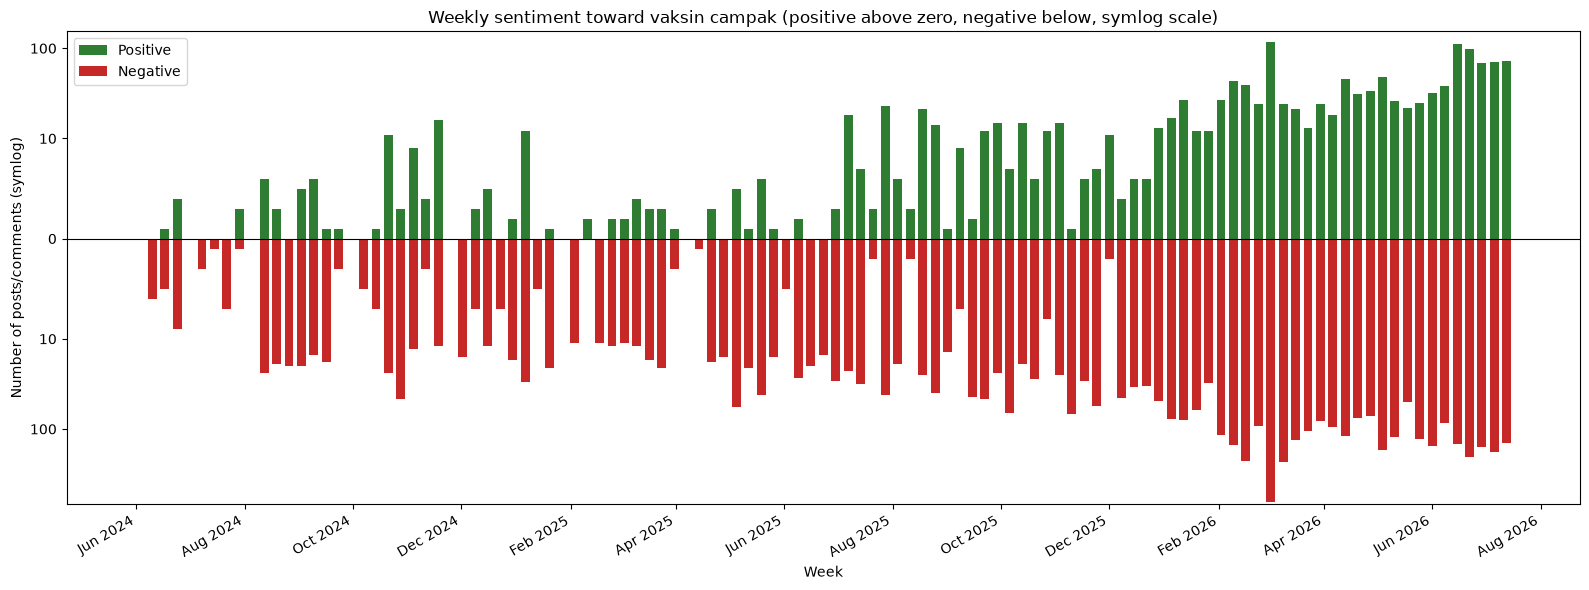

In [8]:
from matplotlib.ticker import ScalarFormatter

PLOT_START = pd.Timestamp('2024-06-01')
weekly_plot = weekly[weekly.index >= PLOT_START]
print(f"plotting {len(weekly_plot)}/{len(weekly)} weeks (from {weekly_plot.index.min().date()})")

LINTHRESH = 10

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(weekly_plot.index, weekly_plot['positive'], width=5, color='#2e7d32', label='Positive')
ax.bar(weekly_plot.index, -weekly_plot['negative'], width=5, color='#c62828', label='Negative')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_yscale('symlog', linthresh=LINTHRESH)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_title('Weekly sentiment toward vaksin campak (positive above zero, negative below, symlog scale)')
ax.set_xlabel('Week')
ax.set_ylabel('Number of posts/comments (symlog)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

yticks = ax.get_yticks()
ax.set_yticklabels([str(int(abs(y))) for y in yticks])

plt.tight_layout()
plt.savefig('weekly_sentiment_diverging.png', dpi=150)
plt.show()

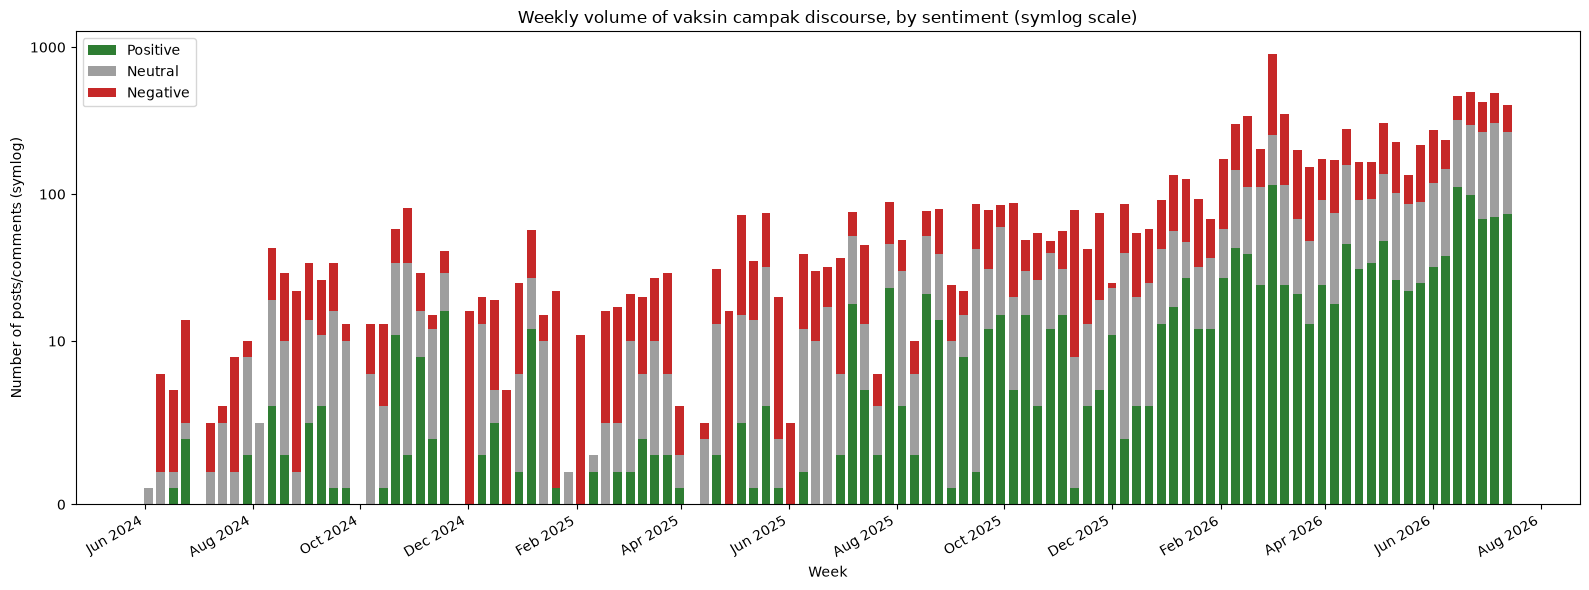

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(weekly_plot.index, weekly_plot['positive'], width=5, color='#2e7d32', label='Positive')
ax.bar(weekly_plot.index, weekly_plot['neutral'], width=5, bottom=weekly_plot['positive'], color='#9e9e9e', label='Neutral')
ax.bar(weekly_plot.index, weekly_plot['negative'], width=5,
       bottom=weekly_plot['positive'] + weekly_plot['neutral'], color='#c62828', label='Negative')

ax.set_yscale('symlog', linthresh=LINTHRESH)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_title('Weekly volume of vaksin campak discourse, by sentiment (symlog scale)')
ax.set_xlabel('Week')
ax.set_ylabel('Number of posts/comments (symlog)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig('weekly_sentiment_stacked.png', dpi=150)
plt.show()

## 7. Save results

Adds `has_parent_context`: `True` for comments whose parent post text was actually found and
prepended (a real, honest context boost), `False` for comments scored on their own text alone
— either because the row isn't a comment, or its parent wasn't present in `cleaned_data.csv`
(true for the majority of comments here — 5824/9540 — since the merge step didn't guarantee
every comment's parent survived). Sentiment on those rows is noisier: a short reply's own text
can carry generic sentiment (e.g. praising a doctor, insulting another commenter) unrelated to
vaccine attitude specifically. Worth filtering on this column if you want a stricter, higher-
precision subset for the writeup.

In [10]:
df['has_parent_context'] = has_parent

out_cols = ['account', 'postdate', 'tweet', 'link', 'replysource', 'platform', 'has_parent_context',
            'context_text', 'sentiment_label', 'sentiment_score', 'week']
df[out_cols].to_csv('cleaned_data_with_sentiment.csv', index=False)
weekly.to_csv('weekly_sentiment_counts.csv')
print('Saved cleaned_data_with_sentiment.csv and weekly_sentiment_counts.csv')

Saved cleaned_data_with_sentiment.csv and weekly_sentiment_counts.csv
